In [173]:
import numpy as np
import pandas as pd

train_df=pd.read_csv('datasets/playground-series-s4e6/train.csv')
test_df=pd.read_csv('datasets/playground-series-s4e6/test.csv')

In [174]:
# train_df.describe()
# train_df.info()
# train_df.head()
# train_df.isna().sum()

In [175]:
# Marital status - right-skewed, max outlier
# Application mode - left-skewed
# Application order - right-skewed, max outlier
# Course - left-skewed, min outlier
# Previous qualification - right-skewed, max outlier
# Previous qualification(grade) - max outlier
# Nacionality - max outlier

In [176]:
def preprocess_data(df):
    df=df.rename(columns={
        'Marital status': 'MaritalStatus',
        'Application mode': 'ApplicationMode',
        'Application order': 'ApplicationOrder',
        'Daytime/evening attendance': 'Attendance',
        'Previous qualification': 'PreviousQualification',
        'Previous qualification (grade)': 'PreviousQualificationGrade',
        'Nacionality': 'Nationality',
        "Mother's qualification": 'MotherQualification',
        "Mother's occupation": 'MotherOccupation',
        "Father's qualification": 'FatherQualification',
        "Father's occupation": 'FatherOccupation',
        'Admission grade': 'AdmissionGrade',
        'Educational special needs': 'EducationalSpecialNeeds',
        'Tuition fees up to date': 'TuitionFeesUpToDate',
        'Scholarship holder': 'ScholarshipHolder',
        'Age at enrollment': 'EnrollmentAge',
        'Unemployment rate': 'UnemploymentRate',
        'Inflation rate': 'InflationRate'
    })

    df['TotalCredited']=df['Curricular units 1st sem (credited)'] + df['Curricular units 2nd sem (credited)']
    df['TotalEnrolled']=df['Curricular units 1st sem (enrolled)'] + df['Curricular units 2nd sem (enrolled)']
    df['TotalEvaluations']=df['Curricular units 1st sem (evaluations)'] + df['Curricular units 2nd sem (evaluations)']
    df['TotalApproved']=df['Curricular units 1st sem (approved)'] + df['Curricular units 2nd sem (approved)']
    df['AverageGrade']=df[['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']].mean(axis=1)
    df['TotalWithoutEvaluations']=df['Curricular units 1st sem (without evaluations)'] + df['Curricular units 2nd sem (without evaluations)']

    df=df.drop(columns=[
        'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)'
    ])
    return df

train_df=preprocess_data(train_df)
test_df=preprocess_data(test_df)

train_df=train_df.drop(columns=['id'])

In [177]:
print(train_df.columns)

Index(['MaritalStatus', 'ApplicationMode', 'ApplicationOrder', 'Course',
       'Attendance', 'PreviousQualification', 'PreviousQualificationGrade',
       'Nationality', 'MotherQualification', 'FatherQualification',
       'MotherOccupation', 'FatherOccupation', 'AdmissionGrade', 'Displaced',
       'EducationalSpecialNeeds', 'Debtor', 'TuitionFeesUpToDate', 'Gender',
       'ScholarshipHolder', 'EnrollmentAge', 'International',
       'UnemploymentRate', 'InflationRate', 'GDP', 'Target', 'TotalCredited',
       'TotalEnrolled', 'TotalEvaluations', 'TotalApproved', 'AverageGrade',
       'TotalWithoutEvaluations'],
      dtype='object')


In [178]:
import seaborn as sns
import matplotlib.pyplot as plt

# for col in train_df.columns:
#     sns.histplot(train_df[col], kde=True)
#     plt.title(f'Histplot - {col}')
#     plt.show()

#     sns.boxplot(train_df[col])
#     plt.title(f'Boxplot - {col}')
#     plt.show()

In [179]:
from scipy.stats import skew

true_numerical_cols=['PreviousQualificationGrade', 'UnemploymentRate', 'InflationRate', 'GDP', 'EnrollmentAge', 'TotalEnrolled', 'TotalEvaluations', 'TotalApproved', 'AverageGrade']
for col in true_numerical_cols:
    Q1=train_df[col].quantile(.25)
    Q3=train_df[col].quantile(.75)
    IQR=Q3-Q1

    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    min_val=train_df[col].min()
    max_val=train_df[col].max()

    if min_val < lower_bound or max_val > upper_bound:
        train_df[col]=train_df[col].clip(
            lower=lower_bound if min_val < lower_bound else None,
            upper=upper_bound if max_val > upper_bound else None
        )
        test_df[col]=test_df[col].clip(
            lower=lower_bound if min_val < lower_bound else None,
            upper=upper_bound if max_val > upper_bound else None
        )
    
    skewness=skew(train_df[col])
    # print(f'Skewness[{col}]: {skewness}')

# EnrollmentAge - very-skewed (2.36)
# AverageGrade - very-skewed (-1.16)
train_df['EnrollmentAge_log']=np.log1p(train_df['EnrollmentAge'])
train_df['AverageGrade_log']=np.log1p(train_df['AverageGrade'])
test_df['EnrollmentAge_log']=np.log1p(test_df['EnrollmentAge'])
test_df['AverageGrade_log']=np.log1p(test_df['AverageGrade'])

In [180]:
# plt.figure(figsize=(10, 6))
# sns.countplot(data=train_df, x='Course', hue='Target')
# plt.show()

# INSIGHTS
# Course 9500 - highest graduate rate, ff. 9773 and 9238
# Course 9147 - highest enrolled
# No course data for 39 or 979
# Nationality 1 - 99%
# MotherOccupation 9 - Most dropouts, graduates, and enrollees
# FatherOccupation 9 - Most dropouts, graduates, and enrollees
# Displace 1 - most graduates
# Gender 0 - most graduates

In [181]:
from sklearn.preprocessing import LabelEncoder
pure_categorical_cols=[
    'ApplicationMode', 'Course', 'PreviousQualification', 'Nationality', 'MotherQualification', 'FatherQualification', 'MotherOccupation', 'FatherOccupation'
]

def label_encode(df):
    le = LabelEncoder()
    df_encoded = df.copy()
    
    for col in pure_categorical_cols:
        df_encoded[col] = le.fit_transform(df_encoded[col])

    return df

train_df=label_encode(train_df)
test_df=label_encode(test_df)

In [182]:
def feature_engineer(df):
    df['TotalParentalOccupation']=df['MotherOccupation'] + df['FatherOccupation']
    df['TotalParentalQualification']=df['MotherQualification'] + df['FatherQualification']
    df['ParentalEduOccScore']=df['TotalParentalOccupation'] * df['TotalParentalQualification']
    df['SuccessRate'] = df['TotalApproved'] / (df['TotalEvaluations'] + 1)
    df['EvaluationEnrollmentRatio'] = df['TotalEvaluations'] / (df['TotalEnrolled'] + 1)

    df['YoungDaytime'] = ((df['Attendance'] == 1) & (df['EnrollmentAge'] < 20)).astype(int)

    df['EconomicStressIndex'] = df['InflationRate'] / (df['GDP'] + 1)

    df['IsFirstChoice'] = (df['ApplicationOrder'] == 1).astype(int)
    df['MultipleApplications'] = (df['ApplicationOrder'] > 1).astype(int)
    return df

train_df=feature_engineer(train_df)
test_df=feature_engineer(test_df)

In [183]:
# corr=train_df.corr(numeric_only=True)
# plt.figure(figsize=(20, 14))
# sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
# plt.title('Feature Correlation Heatmap')
# plt.show()

print(train_df['Target'].value_counts())

Target
Graduate    36282
Dropout     25296
Enrolled    14940
Name: count, dtype: int64


In [184]:
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(train_df['Target'])

In [185]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from catboost import CatBoostClassifier

X=train_df.drop(columns=['Target'])
y=train_df['Target']

X_train, X_val, y_train, y_val=train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

cat_features = [
    # Pure Categorical
    'MaritalStatus', 'ApplicationMode', 'ApplicationOrder', 'Course',
    'PreviousQualification', 'Nationality',
    'MotherQualification', 'FatherQualification',
    'MotherOccupation', 'FatherOccupation', 'Displaced',
    'EducationalSpecialNeeds', 'Debtor', 'Gender',

    'Attendance', 'TuitionFeesUpToDate', 'ScholarshipHolder', 'International'
]

model=CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    eval_metric='Accuracy',
    class_weights=[1.0, 1.5, 2.0], 
    verbose=100
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

# Predict (already numeric)
predictions = model.predict(X_val)

# For human-readable reports:
predictions_decoded = le_target.inverse_transform(predictions)
y_val_decoded = le_target.inverse_transform(y_val)

accuracy = accuracy_score(y_val, predictions)

Class distribution analysis:
Graduate: 36282 (47.4%)
Dropout: 25296 (33.1%)
Enrolled: 14940 (19.5%)

Inverse frequency weights: [0.70299322 1.00830171 1.70722892]

TRYING DATA RESAMPLING APPROACHES
Applying SMOTE oversampling...

TESTING: AUTO BALANCED
0:	learn: 1.0692730	test: 1.0693099	best: 1.0693099 (0)	total: 88ms	remaining: 2m 11s
100:	learn: 0.5406794	test: 0.5456145	best: 0.5456145 (100)	total: 9.02s	remaining: 2m 5s
200:	learn: 0.5113149	test: 0.5213591	best: 0.5213591 (200)	total: 19.2s	remaining: 2m 4s
300:	learn: 0.4967410	test: 0.5139314	best: 0.5139314 (300)	total: 29.5s	remaining: 1m 57s
400:	learn: 0.4848446	test: 0.5098884	best: 0.5098884 (400)	total: 39.7s	remaining: 1m 48s
500:	learn: 0.4735970	test: 0.5063700	best: 0.5063700 (500)	total: 49.7s	remaining: 1m 39s
600:	learn: 0.4638909	test: 0.5042014	best: 0.5042014 (600)	total: 59.9s	remaining: 1m 29s
700:	learn: 0.4559284	test: 0.5030629	best: 0.5030446 (699)	total: 1m 10s	remaining: 1m 20s
800:	learn: 0.4481625	tes

In [186]:
# Convert probabilities to class labels if needed
if predictions.ndim == 2:
    predictions = predictions.argmax(axis=1)

# Assuming 'le_target' is your LabelEncoder used on y:
predictions_decoded = le_target.inverse_transform(predictions)

# Now use:
report = classification_report(y_val_decoded, predictions_decoded, output_dict=True)

C:\Users\dreyyan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dreyyan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dreyyan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

[ ACCURACY ]


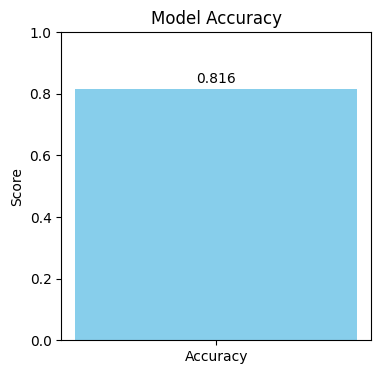

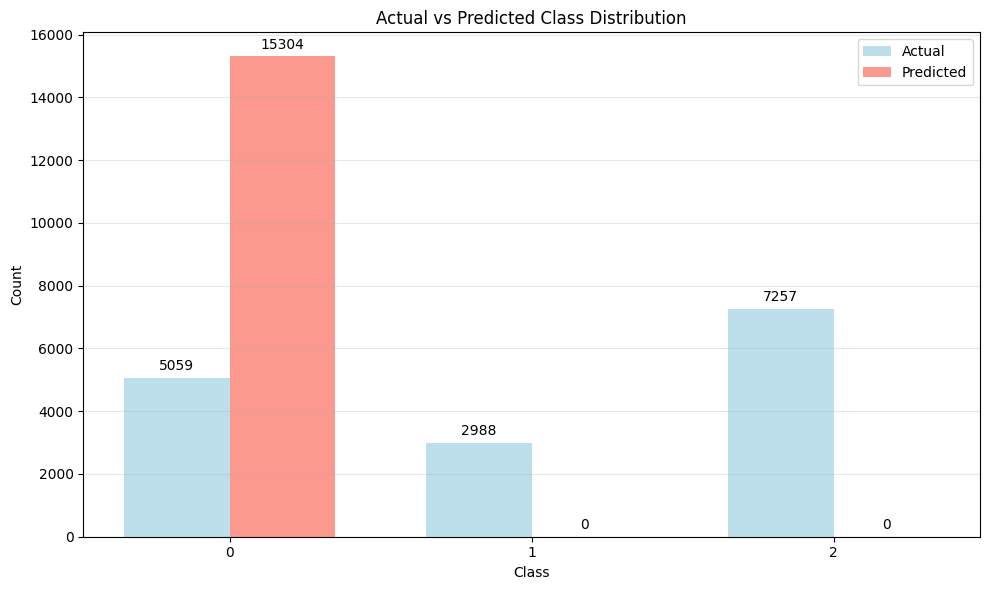

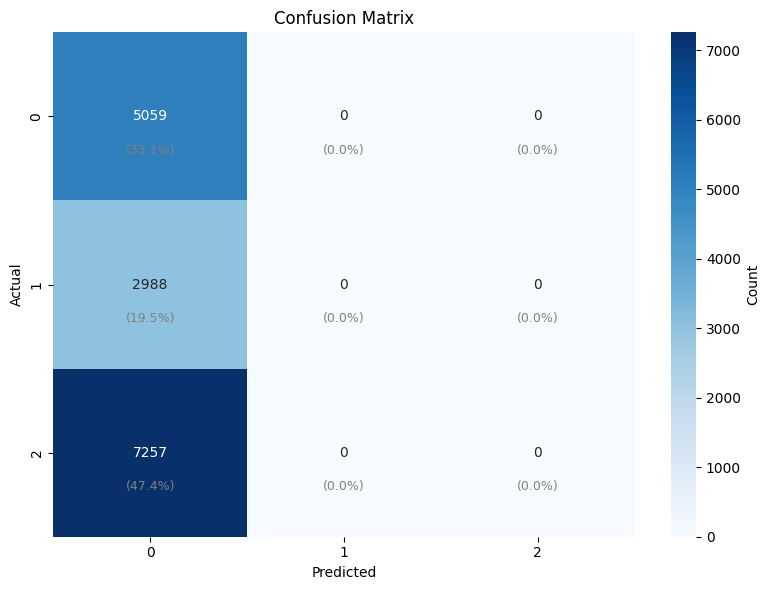

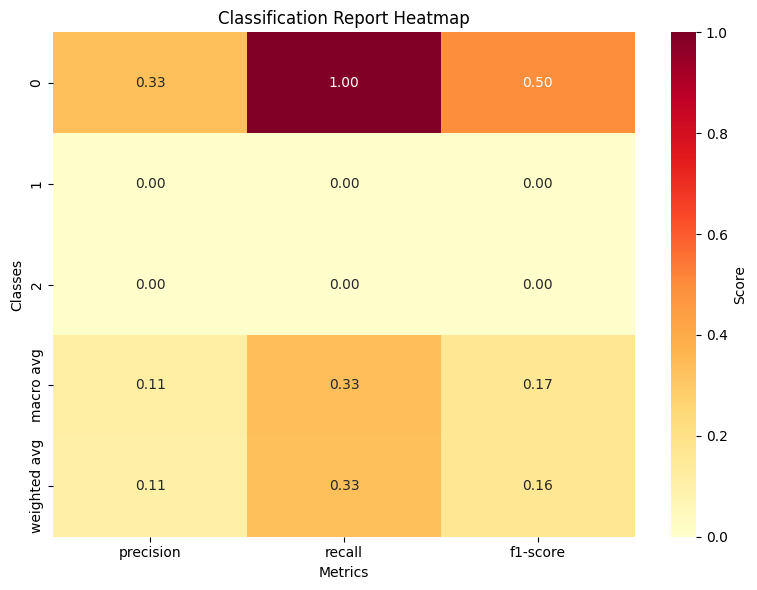

<Figure size 1200x800 with 0 Axes>

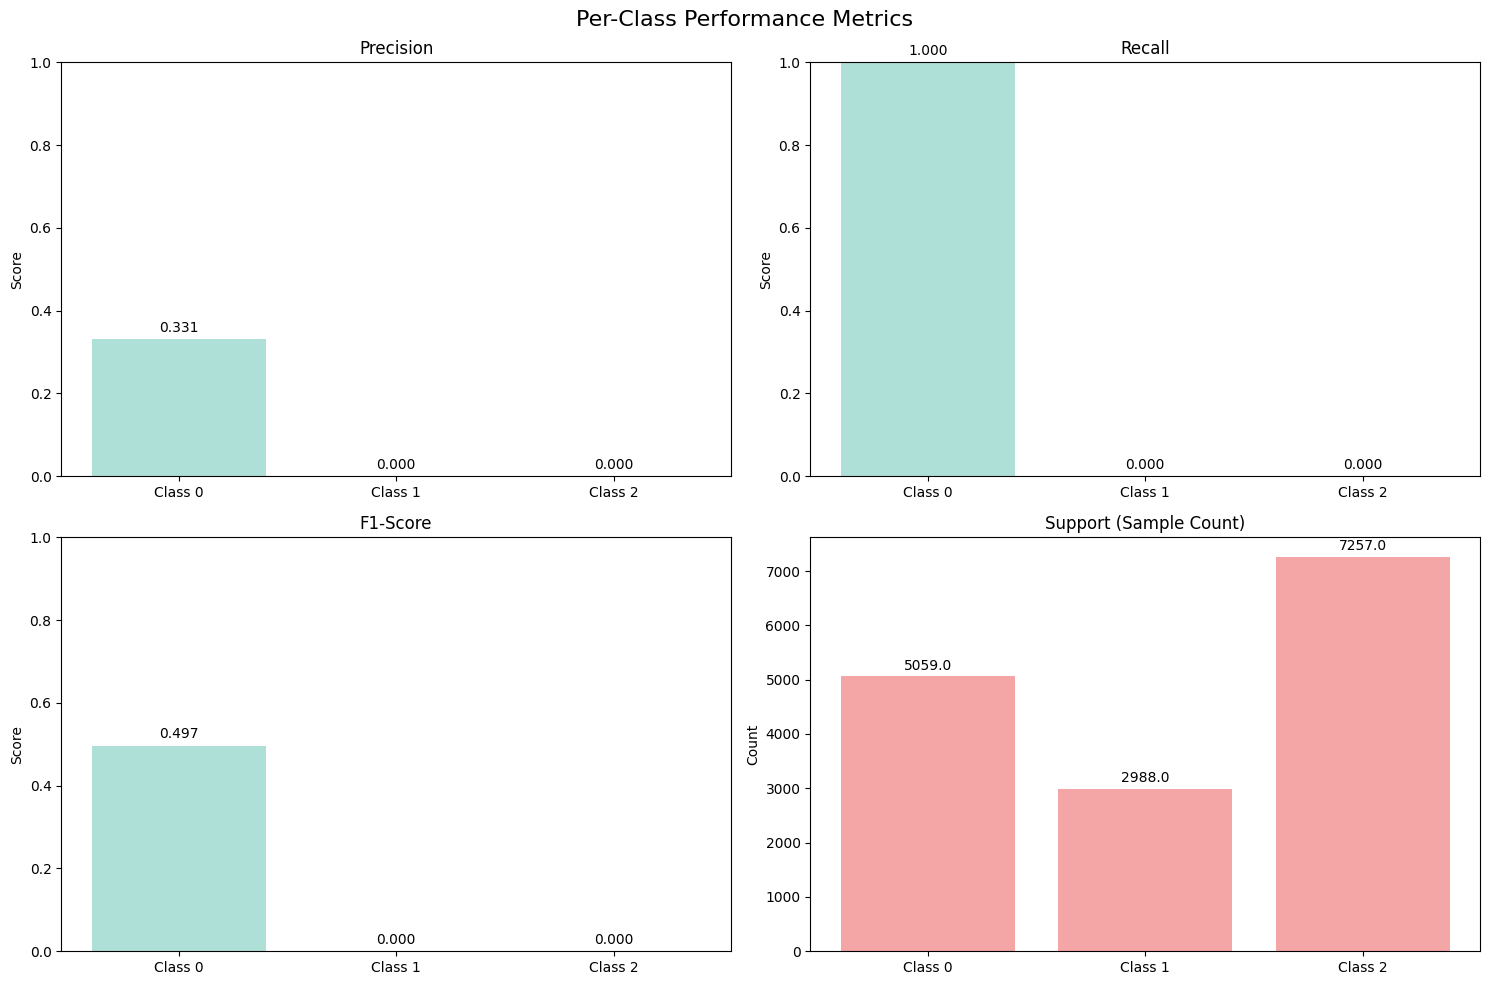

0:	learn: 1.0729267	total: 20.7ms	remaining: 41.5s
100:	learn: 0.4122495	total: 2.17s	remaining: 40.9s
200:	learn: 0.3573506	total: 4.36s	remaining: 39s
300:	learn: 0.3452728	total: 6.49s	remaining: 36.6s
400:	learn: 0.3389655	total: 8.64s	remaining: 34.5s
500:	learn: 0.3340025	total: 10.8s	remaining: 32.3s
600:	learn: 0.3293083	total: 13s	remaining: 30.2s
700:	learn: 0.3251559	total: 15.1s	remaining: 28.1s
800:	learn: 0.3214312	total: 17.3s	remaining: 25.8s
900:	learn: 0.3182607	total: 19.4s	remaining: 23.6s
1000:	learn: 0.3153195	total: 21.5s	remaining: 21.4s
1100:	learn: 0.3124678	total: 23.6s	remaining: 19.3s
1200:	learn: 0.3100024	total: 25.7s	remaining: 17.1s
1300:	learn: 0.3076699	total: 27.8s	remaining: 15s
1400:	learn: 0.3052373	total: 29.9s	remaining: 12.8s
1500:	learn: 0.3030473	total: 32s	remaining: 10.7s
1600:	learn: 0.3008492	total: 34.1s	remaining: 8.51s
1700:	learn: 0.2986551	total: 36.2s	remaining: 6.37s
1800:	learn: 0.2965376	total: 38.4s	remaining: 4.24s
1900:	learn:

In [ ]:
# 1. Accuracy - Bar Plot
print("[ ACCURACY ]")
plt.figure(figsize=(4, 4))
plt.bar(["Accuracy"], [accuracy], color='skyblue')
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()

# 2. Actual vs Predicted - Bar Chart (Fixed)
results_df = pd.DataFrame({
    'Actual': pd.Series(y_val).reset_index(drop=True),
    'Predicted': pd.Series(predictions).reset_index(drop=True)
})


melted = results_df.melt(var_name='Type', value_name='Class')

plt.figure(figsize=(8, 4))
sns.countplot(
    data=melted,
    x='Class', hue='Type',
    palette='pastel'
)
plt.title("Actual vs Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title='Label Type')
plt.show()

# 3. Confusion Matrix - Heatmap (Fixed for Multiclass)
labels = model.classes_
cm = confusion_matrix(y_val, predictions, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4. Precision, Recall, F1 Score - Heatmap (Multiclass)
report = classification_report(y_val, predictions, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).drop(columns=['accuracy'])

plt.figure(figsize=(8, 5))
sns.heatmap(report_df.iloc[:-1, :].T, annot=True, cmap="YlGnBu", fmt=".2f")  # Exclude 'macro avg', etc., if preferred
plt.title("Classification Report")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# 5. Cross-Validation Scores - Bar Plot
scores = cross_val_score(model, X, y, cv=3)

plt.figure(figsize=(8, 4))
plt.bar(range(1, 4), scores, color='lightgreen')
plt.ylim(0, 1)
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 4))
plt.show()
